In [1]:
import os
import json
import random
import time
import copy
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, datasets, transforms

import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as metrics

DATASET_ROOT = Path("..") / "smartvision_dataset"
NEW_CLASSIFICATION_DIR = DATASET_ROOT / "classification_v2"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(root=NEW_CLASSIFICATION_DIR / "train", transform=train_transform)
val_dataset   = datasets.ImageFolder(root=NEW_CLASSIFICATION_DIR / "val", transform=eval_transform)
test_dataset  = datasets.ImageFolder(root=NEW_CLASSIFICATION_DIR / "test", transform=eval_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

NUM_CLASSES = len(train_dataset.classes)
print(f"Classes: {NUM_CLASSES} | Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: 25 | Train: 1750 | Val: 375 | Test: 375


In [3]:
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze everything first
for param in efficientnet.parameters():
    param.requires_grad = False

# Unfreeze the last two feature blocks for fine-tuning
for param in efficientnet.features[7].parameters():
    param.requires_grad = True
for param in efficientnet.features[8].parameters():
    param.requires_grad = True

# Custom head with batch normalization (per your plan's Step 2.4)
efficientnet.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(1280, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, NUM_CLASSES)
)

efficientnet = efficientnet.to(device)

trainable = sum(p.numel() for p in efficientnet.parameters() if p.requires_grad)
total = sum(p.numel() for p in efficientnet.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

0.6%

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100.0%


Trainable params: 1,464,265 / 4,342,421


In [4]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam([
    {"params": efficientnet.features[7].parameters(), "lr": 1e-5, "weight_decay": 1e-4},
    {"params": efficientnet.features[8].parameters(), "lr": 1e-5, "weight_decay": 1e-4},
    {"params": efficientnet.classifier.parameters(), "lr": 1e-3, "weight_decay": 1e-4},
])

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
print("Optimizer ready.")

Optimizer ready.


In [5]:
EPOCHS = 10
best_val_acc = 0.0
best_model_weights = copy.deepcopy(efficientnet.state_dict())
patience = 5
epochs_no_improve = 0

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    start_time = time.time()

    efficientnet.train()
    running_loss, running_correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = efficientnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = running_correct / total

    efficientnet.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = efficientnet(images)
            loss = criterion(outputs, labels)
            val_loss_sum += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} ({elapsed:.1f}s) - "
          f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
          f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(efficientnet.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

efficientnet.load_state_dict(best_model_weights)
print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 1/10 (23.0s) - train_loss: 2.4387, train_acc: 0.3726, val_loss: 1.5576, val_acc: 0.6800
Epoch 2/10 (22.3s) - train_loss: 1.4588, train_acc: 0.6486, val_loss: 1.1115, val_acc: 0.7440
Epoch 3/10 (22.1s) - train_loss: 1.1296, train_acc: 0.7091, val_loss: 0.9315, val_acc: 0.7840
Epoch 4/10 (22.6s) - train_loss: 0.9518, train_acc: 0.7526, val_loss: 0.8278, val_acc: 0.7973
Epoch 5/10 (22.8s) - train_loss: 0.7979, train_acc: 0.7823, val_loss: 0.7730, val_acc: 0.7947
Epoch 6/10 (23.2s) - train_loss: 0.6951, train_acc: 0.8177, val_loss: 0.7536, val_acc: 0.8053
Epoch 7/10 (22.6s) - train_loss: 0.6141, train_acc: 0.8326, val_loss: 0.7389, val_acc: 0.8000
Epoch 8/10 (23.8s) - train_loss: 0.5885, train_acc: 0.8371, val_loss: 0.7000, val_acc: 0.8080
Epoch 9/10 (22.6s) - train_loss: 0.4907, train_acc: 0.8697, val_loss: 0.7166, val_acc: 0.8160
Epoch 10/10 (23.4s) - train_loss: 0.5065, train_acc: 0.8497, val_loss: 0.6910, val_acc: 0.8213

Best validation accuracy: 0.8213


In [6]:
EPOCHS = 10

for epoch in range(EPOCHS):
    start_time = time.time()

    efficientnet.train()
    running_loss, running_correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = efficientnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = running_correct / total

    efficientnet.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = efficientnet(images)
            loss = criterion(outputs, labels)
            val_loss_sum += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} ({elapsed:.1f}s) - "
          f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
          f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(efficientnet.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

efficientnet.load_state_dict(best_model_weights)
print(f"\nBest validation accuracy so far: {best_val_acc:.4f}")

Epoch 1/10 (23.0s) - train_loss: 0.4545, train_acc: 0.8629, val_loss: 0.6895, val_acc: 0.8240
Epoch 2/10 (22.9s) - train_loss: 0.4292, train_acc: 0.8703, val_loss: 0.7122, val_acc: 0.8213
Epoch 3/10 (24.3s) - train_loss: 0.3884, train_acc: 0.8931, val_loss: 0.6929, val_acc: 0.8267
Epoch 4/10 (23.1s) - train_loss: 0.3584, train_acc: 0.8954, val_loss: 0.6877, val_acc: 0.8427
Epoch 5/10 (23.2s) - train_loss: 0.3575, train_acc: 0.8943, val_loss: 0.6796, val_acc: 0.8400
Epoch 6/10 (22.6s) - train_loss: 0.3201, train_acc: 0.9034, val_loss: 0.6953, val_acc: 0.8347
Epoch 7/10 (22.6s) - train_loss: 0.3479, train_acc: 0.9000, val_loss: 0.7170, val_acc: 0.8187
Epoch 8/10 (22.5s) - train_loss: 0.3439, train_acc: 0.8949, val_loss: 0.7180, val_acc: 0.8240
Epoch 9/10 (22.5s) - train_loss: 0.3150, train_acc: 0.9057, val_loss: 0.7084, val_acc: 0.8187
Early stopping triggered at epoch 9

Best validation accuracy so far: 0.8427


In [7]:
os.makedirs("../models", exist_ok=True)
torch.save(efficientnet.state_dict(), "../models/efficientnetb0_best.pth")
print("Model saved to ../models/efficientnetb0_best.pth")

efficientnet.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = efficientnet(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = metrics.accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(metrics.classification_report(all_labels, all_preds, target_names=test_dataset.classes))

Model saved to ../models/efficientnetb0_best.pth

Test Accuracy: 0.7760

Classification Report:
               precision    recall  f1-score   support

     airplane       0.88      0.93      0.90        15
          bed       0.76      0.87      0.81        15
        bench       0.83      0.67      0.74        15
      bicycle       0.70      0.93      0.80        15
         bird       0.93      0.93      0.93        15
       bottle       0.89      0.53      0.67        15
         bowl       0.55      0.73      0.63        15
          bus       0.63      0.80      0.71        15
         cake       0.75      0.80      0.77        15
          car       0.50      0.33      0.40        15
          cat       1.00      0.80      0.89        15
        chair       0.52      0.80      0.63        15
        couch       0.86      0.80      0.83        15
          cow       0.83      1.00      0.91        15
          cup       0.69      0.73      0.71        15
          dog       0.9

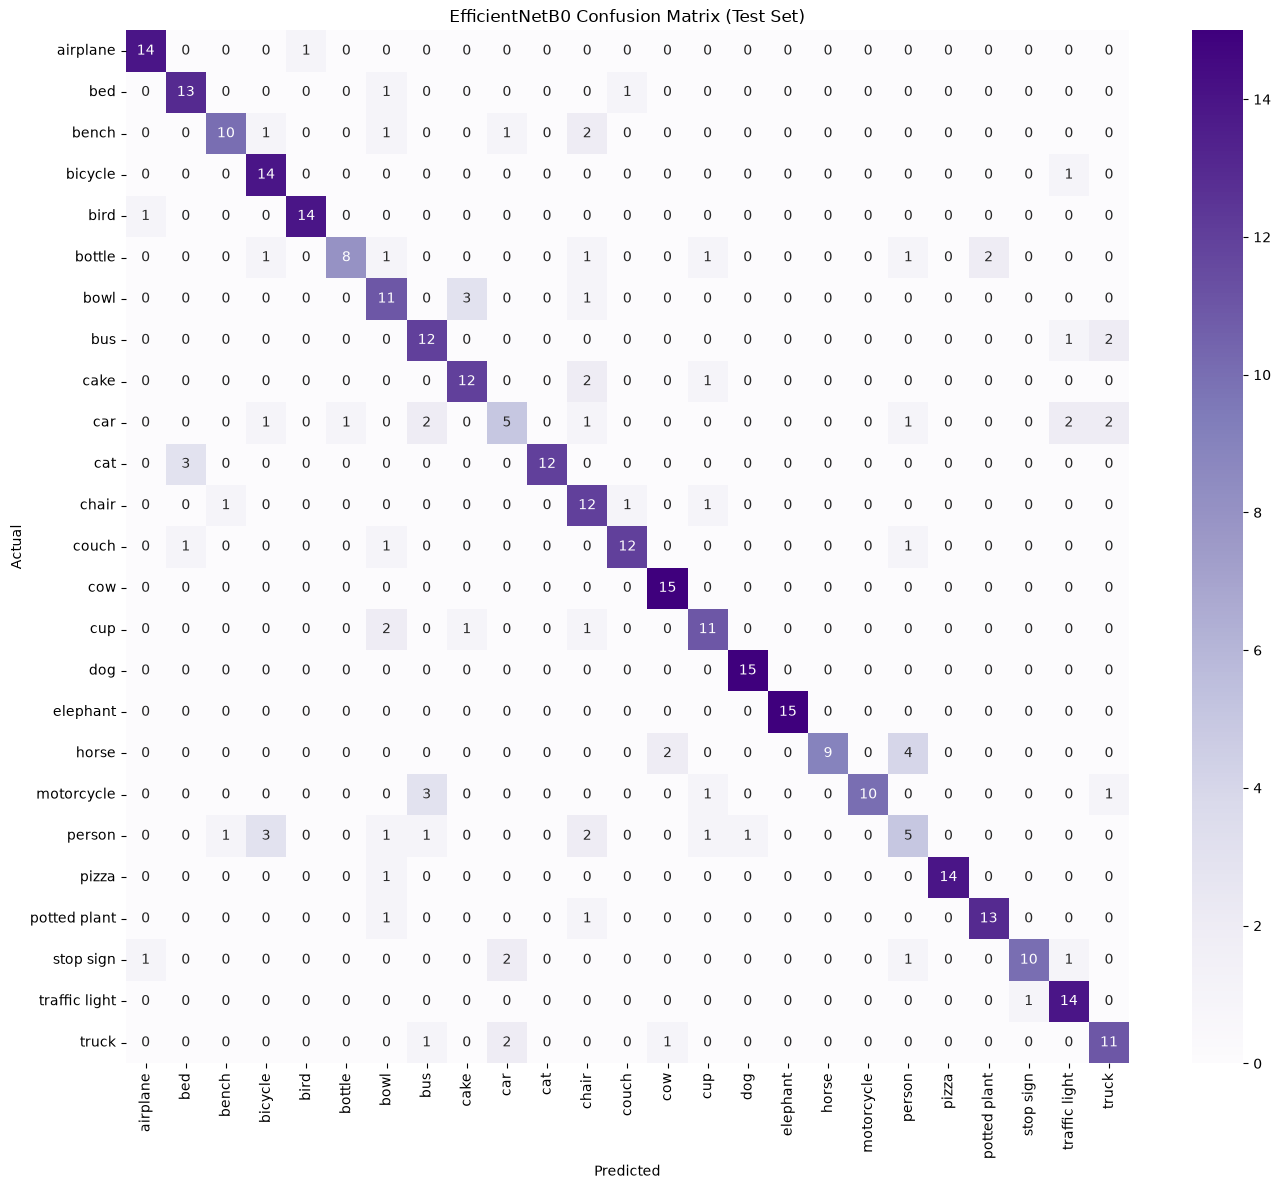

In [8]:
cm = metrics.confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNetB0 Confusion Matrix (Test Set)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/confusion_matrices/efficientnetb0_confusion_matrix.png")
plt.show()